In [1]:
import time

from utils import plot_gradient_descent

# Gradient Descent: The Engine of Optimization

In many fields, like business, engineering and machine learning, we are constantly trying to optimize things. We may want to maximize profits, minimize fuel consumption or minimize the errors in an AI model.

A helpful way to think about gradient descent is to imagine you are blindfolded at the top of a rugged mountain, and your goal is to find the lowest point in the valley. You can't see the whole mountain, but you can feel the slope of the ground right beneath your feet. If you repeatedly take a step in the direction that slopes downward the steepest, you will eventually reach the bottom.

That is the core idea behind **gradient descent**.

## Key Concepts

### The Cost Function
In mathematics, our "mountain" is represented by a **cost function**, usually written as $J(\theta)$ or simply $f(x)$. The goal is to find the input $x$ that produces the smallest possible output of $f(x)$.

### The Derivative:
To figure out which way is "down," we use calculus. The derivative of a function, denoted as $f'(x)$ or $\frac{df}{dx}$, gives us the slope of the tangent line at any given point.

### The Gradient:
If a function has multiple variables (like moving in 3D space instead of a 2D line), we use **the gradient** instead of a single derivative. The gradient, denoted by the symbol $\nabla$, is a vector containing all the partial derivatives of the function.

### The Rule:
The gradient $\nabla f(x)$ always points in the direction of the **steepest ascent** (up the mountain). Since we want to find the minimum, we must move in the opposite direction: 

$-\nabla f(x)$.

### The update rule equation:
This is the rule that tells us how to move step by step toward the minimum. It is how we actually steer the model in the right direction.

The algorithm starts at a random point $x_0$, and iteratively updates its position using the following formula:

$$x_{n+1} = x_n - \alpha \nabla f(x_n)$$

#### Variables:
| Variable | Description |
|--------|-------------|
| $x_n$ | The current position |
| $x_{n+1}$ | The next position |
| $\nabla f(x_n)$ | The gradient (slope) at the current position. |
| $\alpha$ | The learning rate |

##### Why the Minus Sign?
The gradient points uphill, in the direction of greatest increase. To move downhill toward a minimum, we subtract the gradient instead of adding it.

## Learning Rate and constraints

The Learning Rate ($\alpha$) controls how big of a step we want to take.

**Constraint 1**: If $\alpha$ is too small, the algorithm will take tiny steps. That means it will eventually reach the minimum, but this would be incredibly slow.

**Constraint 2**: If $\alpha$ is too big, the algorithm will take massive steps. It is very likely that it will completely step over the minimum and just bounce back and forth, never finding the minimum.

### Choosing a Good Learning Rate
A good learning rate helps the algorithm make meaningful progress without overshooting. In practice, the step size should be large enough to learn efficiently, but small enough to remain stable.

# Code
## 1. Defining the Target Function

To test our algorithm, we need a mathematical function to minimize. We will use a simple quadratic function:
$$f(x) = x^2$$

To use gradient descent, we also need the derivative (the gradient) of this function. Using basic power rule calculus, the derivative is:
$$f'(x) = 2x$$

In [2]:
def f(x:float) -> float:
    """
    The cost function we want to minimize: f(x) = x^2
    """
    return x ** 2

def df(x:float) -> float:
    """
    The derivative of the cost function: f'(x) = 2x
    This gives us the slope (gradient) at any point x.
    """
    return 2 * x

print(f"When x is 3, f(x) is {f(3)} and the slope is {df(3)}.")

When x is 3, f(x) is 9 and the slope is 6.


## 2. The Gradient Descent Algorithm

Now we will translate our math equation into Python. Our function will take a starting position, a learning rate ($\alpha$), and a set number of iterations. 

It will keep track of its "history" (every step it takes) so we can visualize its path down the mountain later.

In [3]:
def gradient_descent(starting_x: float, learning_rate: float, num_iterations: int) -> tuple[float, list[float], float]:
    """
    Performs gradient descent to find the minimum of a function.
    
    Parameters:
    starting_x (float): The initial random guess for x.
    learning_rate (float): The step size (alpha).
    num_iterations (int): How many steps to take.
    
    Returns:
    tuple: The final x value, a list containing the history of all x values, and the elapsed time.
    """

    start = time.perf_counter()
    x = starting_x
    history = [x]

    for _ in range(num_iterations):
        # 1. Calculate the gradient at the current position
        gradient = df(x)

        # 2. Update the position using the gradient descent formula
        x = x - (learning_rate * gradient)

        # 3. Save the new x value to history
        history.append(x)

    end = time.perf_counter()
    elapsed_time = end - start
    return x, history, elapsed_time

# Test the gradient descent function
final_x_first, step_history_first, elapsed_time_first = gradient_descent(starting_x=4.0, learning_rate=0.1, num_iterations=20)

print(f"Final x value: {final_x_first:.4f}. Done in {elapsed_time_first:7f} seconds.")
print(f"Did it reach very close to the minimum (0)? {'Yes' if abs(final_x_first) < 0.1 else 'Not quite yet'}")

# I played around with the learning rate and number of iterations to see how it affects convergence.
# I think I found a really good learning rate that allows us to get close to the minimum in just 3 steps.
final_x_second, step_history_second, elapsed_time_second = gradient_descent(starting_x=4.0, learning_rate=0.55, num_iterations=3)
print(f"Final x value with higher learning rate: {final_x_second:.4f}. Done in {elapsed_time_second:7f} seconds.")
print(f"Did the second run reach very close to the minimum (0)? {'Yes' if abs(final_x_second) < 0.1 else 'Not quite yet'}")

print(f"Is the second run faster than the first? {'Yes' if elapsed_time_second < elapsed_time_first else 'No'}")

Final x value: 0.0461. Done in 0.000008 seconds.
Did it reach very close to the minimum (0)? Yes
Final x value with higher learning rate: -0.0040. Done in 0.000003 seconds.
Did the second run reach very close to the minimum (0)? Yes
Is the second run faster than the first? Yes


## 3. Visualizing the Path to the Minimum

Now I will show you the algorithm in action.

We will plot our cost function, $f(x) = x^2$, as a continuous curve. Then, we will take the `history` of positions from our first gradient descent run and plot them as points on the curve to see how the algorithm navigated down the slope.

The first plot is the one with lower learning rate and more steps.

The second one is the one with a higher learning rate and less steps. This is how an optimized learning rate gradient descent looks like.

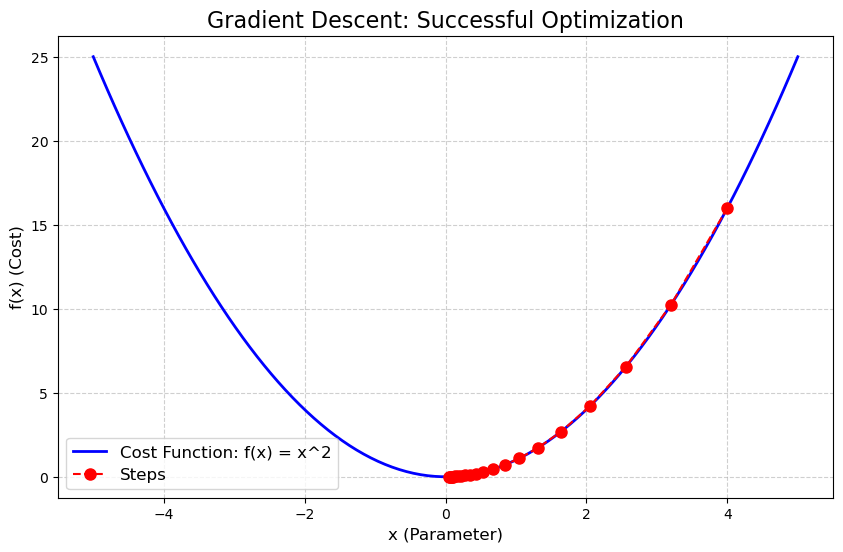

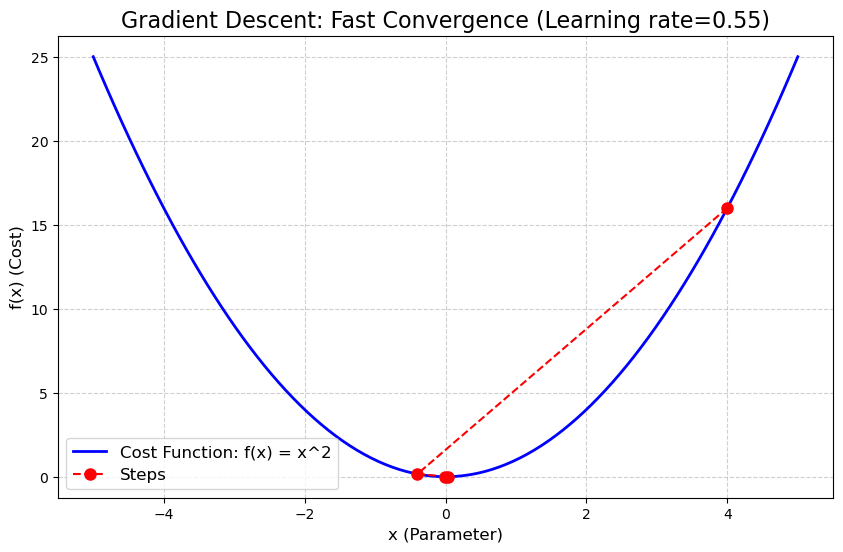

In [4]:
plot_gradient_descent(step_history_first, f=f, title="Gradient Descent: Successful Optimization")
plot_gradient_descent(step_history_second, f=f, title="Gradient Descent: Fast Convergence (Learning rate=0.55)")

### Experiment: The 'Perfect' Scenario (Theoretical)

For our specific quadratic function $f(x) = x^2$, there is actually a 'perfect' learning rate. Because the update rule is $x_{n+1} = x_n(1 - 2\alpha)$, setting $\alpha = 0.5$ will mathematically result in $x = 0$ in exactly one step, regardless of the starting point.

Note: While this is a fun mathematical property of simple parabolas, this 'perfect' scenario is practically impossible in real-world machine learning. Real cost functions are highly complex and non-convex, meaning we must rely on small, iterative steps rather than a single perfect leap.

Final x value with perfect learning rate: 0.0000
Notice how it reached exactly 0.0 in step 2: [4.0, 0.0, 0.0, 0.0]


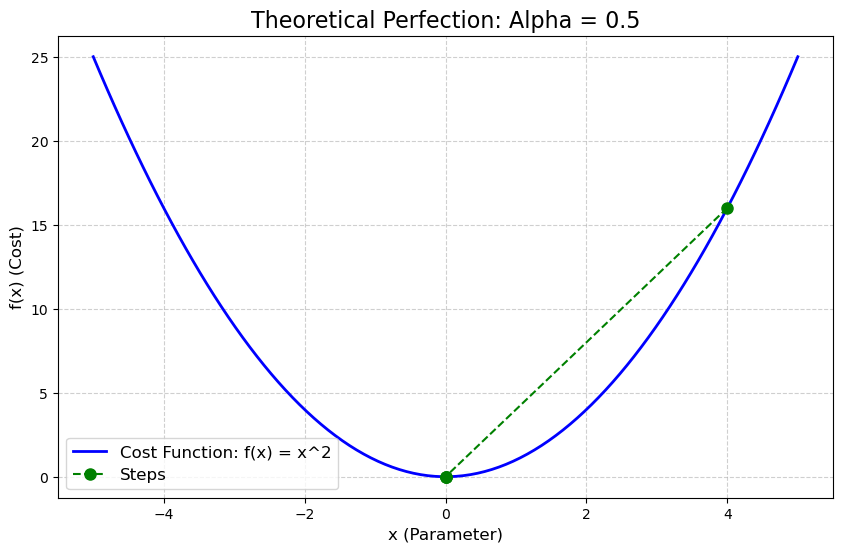

In [5]:
# The "Perfect" Scenario
final_x_perfect, step_history_perfect, elapsed_time_perfect = gradient_descent(starting_x=4.0, learning_rate=0.5, num_iterations=3)

print(f"Final x value with perfect learning rate: {final_x_perfect:.4f}")
print(f"Notice how it reached exactly 0.0 in step 2: {step_history_perfect}")

plot_gradient_descent(step_history_perfect, f=f, title="Theoretical Perfection: Alpha = 0.5", path_color="green")

## 4. Experiment: The Danger of a High Learning Rate (Divergence)

What happens if we set our learning rate ($\alpha$) too high? 

Instead of taking careful steps down the mountain, the algorithm will take a massive leap. It might leap completely over the valley to the other side, ending up higher than it started! If it keeps doing this, it will bounce back and forth, getting further and further away from the minimum. This is called **divergence**.

Let's run our function with $\alpha = 1.05$ and visualize the failure.

Final x value with high learning rate: -4.8315.
It actually moved away from the starting point! This is a sign of divergence.


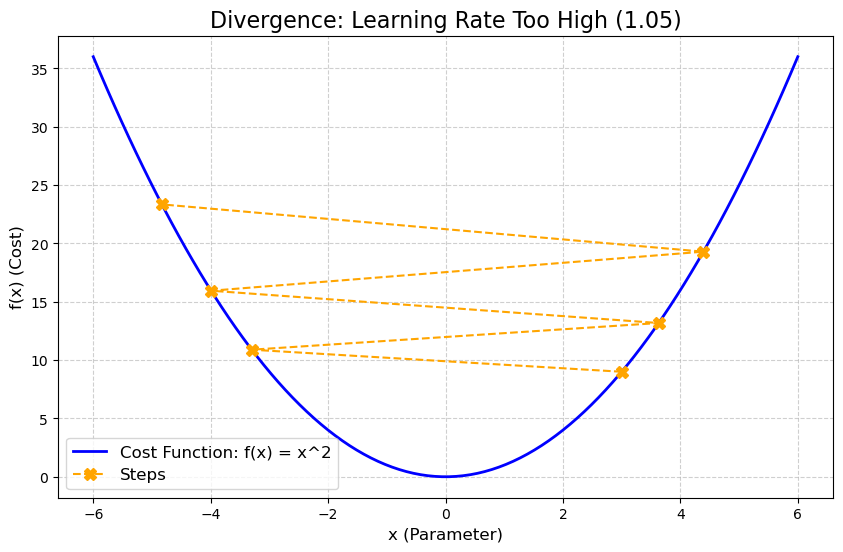

In [6]:
# Run the algorithm with a high learning rate
# We only take 5 steps because it will grow out of control very quickly!
final_x_bad, step_history_bad, time_bad = gradient_descent(starting_x=3.0, learning_rate=1.05, num_iterations=5)
print(f"Final x value with high learning rate: {final_x_bad:.4f}.")
print("It actually moved away from the starting point! This is a sign of divergence.")

plot_gradient_descent(step_history_bad, f=f, title="Divergence: Learning Rate Too High (1.05)", x_bounds=(-6, 6), path_color="orange", path_marker="X")

## 5. Experiment: The Danger of a Low Learning Rate (Slow Convergence)

We saw what happens when $\alpha$ is too high, but what if we are overly cautious and set it too low?

If $\alpha$ is tiny, the algorithm will mathematically guarantee a path to the minimum, but it will take painfully small steps. In real-world machine learning, this means training a model could take weeks instead of hours, wasting expensive computing power. Also, if we limit the number of steps (iterations), it might stop before it ever reaches the bottom.

Let's test this with $\alpha = 0.01$ and limit it to 15 steps.

Final x value after 15 steps: 2.9543
Notice how it barely moved from the starting point of 4.0!


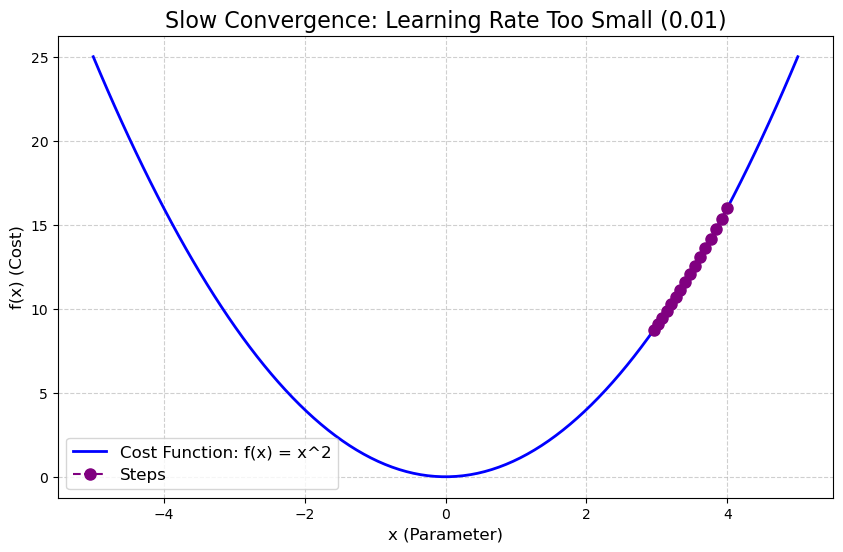

In [7]:
# Run the algorithm with a very small learning rate
final_x_slow, step_history_slow, time_slow = gradient_descent(starting_x=4.0, learning_rate=0.01, num_iterations=15)

print(f"Final x value after 15 steps: {final_x_slow:.4f}")
print("Notice how it barely moved from the starting point of 4.0!")

# Plot the results
plot_gradient_descent(
    step_history=step_history_slow,
    f=f,
    title="Slow Convergence: Learning Rate Too Small (0.01)",
    path_color="purple"
)

## 6. Conclusion and Next Steps

In this project, we successfully implemented Gradient Descent from scratch to minimize a quadratic cost function. By translating the mathematical concepts of derivatives and gradients into Python code, we demonstrated how optimization algorithms find the minimum of a function.

Through our experiments, we also showed the importance of tuning the **learning rate**:
* A well-tuned learning rate leads to fast, stable convergence.
* A learning rate that is too high causes the algorithm to diverge and fail completely.
* A learning rate that is too low mathematically guarantees convergence, but at an impractically slow computational speed.

**Next Steps:** While standard Gradient Descent is a powerful foundation, it has limitations in highly complex, multi-dimensional landscapes (such as getting stuck in "local minima" instead of the true global minimum). A natural next step for this research would be to explore and implement more advanced optimization algorithms that build upon this concept, such as Gradient Descent with Momentum, RMSprop, or the Adam optimizer.

## 7. References and Sources

### References
The mathematical background and intuition in this notebook were informed by the following resources:

- Deisenroth, M. P., Faisal, A. A., & Ong, C. S. (2020). *Mathematics for Machine Learning*. Cambridge University Press. Chapter 7: Continuous Optimization.
- Sanderson, G. (3Blue1Brown). (2017). *Gradient descent, how neural networks learn*. YouTube.

### Tools and Libraries
The implementation and visualizations in this project were developed in Python using the following tools and libraries:

- Python Software Foundation. *Python Documentation*.
- Harris, C. R., et al. (2020). *Array programming with NumPy*. *Nature, 585*(7825), 357-362.
- Hunter, J. D. (2007). *Matplotlib: A 2D graphics environment*. *Computing in Science & Engineering, 9*(3), 90-95.
